# Машинный перевод с механизмом внимания на PyTorch

В этом уроке мы реализуем машинный перевод (Neural Machine Translation, NMT) с использованием глубоких нейронных сетей и механизма внимания (attention). Все примеры основаны на библиотеке PyTorch.

Мы обучим модель последовательность-в-последовательность (sequence-to-sequence) для перевода с английского языка на русский. Если вы не знакомы с моделями последовательность-в-последовательность, в конце урока приведены ссылки на полезные материалы.

Архитектура модели:

- **Encoder** — кодирует входное английское предложение в векторное представление.
- **Механизм внимания (Bahdanau)** — позволяет декодеру "фокусироваться" на нужных словах входного предложения при генерации каждого слова перевода.
- **Decoder** — последовательно генерирует слова перевода на русском языке.

Учебный курс "[Программирование глубоких нейронных сетей на Python](https://openedu.ru/course/urfu/PYDNN/)".


## Импорт библиотек

In [70]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import time
import zipfile
import urllib.request
import os
import unicodedata

%matplotlib inline

print(f"Версия PyTorch: {torch.__version__}")


Версия PyTorch: 2.1.2+cu121


## Данные для обучения

Используем параллельный корпус английский-русский из проекта [Tatoeba](https://tatoeba.org/), доступный по адресу [manythings.org/anki](https://www.manythings.org/anki/). Файл `rus-eng.zip` содержит пары предложений: `английский` (табуляция) `русский` (табуляция) `атрибуция`.

Данные загружаются автоматически. Если загрузка недоступна (например, нет интернета), используется небольшой встроенный набор примеров — этого достаточно, чтобы проверить работу всей модели.


In [71]:
# # Количество пар предложений для обучения (можно уменьшить для ускорения вычислений)
# num_examples = 30000

# url = 'https://www.manythings.org/anki/rus-eng.zip'
# zip_path = 'rus-eng.zip'

# def load_data_from_zip(zip_path):
#     with zipfile.ZipFile(zip_path) as z:
#         with z.open('rus.txt') as f:
#             return f.read().decode('utf8').strip().split('\n')

# # Небольшой встроенный набор на случай, если загрузка недоступна
# fallback_pairs = [
#     "hello\tпривет\t",
#     "hi\tпривет\t",
#     "good morning\tдоброе утро\t",
#     "good evening\tдобрый вечер\t",
#     "good night\tспокойной ночи\t",
#     "goodbye\tдо свидания\t",
#     "see you later\tувидимся позже\t",
#     "thank you\tспасибо\t",
#     "thanks\tспасибо\t",
#     "you are welcome\tпожалуйста\t",
#     "please\tпожалуйста\t",
#     "how are you\tкак у тебя дела\t",
#     "i am fine\tу меня всё хорошо\t",
#     "i am a student\tя студент\t",
#     "i am a teacher\tя учитель\t",
#     "i live in moscow\tя живу в москве\t",
#     "i love you\tя люблю тебя\t",
#     "i like coffee\tя люблю кофе\t",
#     "i like tea\tя люблю чай\t",
#     "i read books\tя читаю книги\t",
#     "i drink water\tя пью воду\t",
#     "i love my family\tя люблю свою семью\t",
#     "what is your name\tкак тебя зовут\t",
#     "my name is tom\tменя зовут том\t",
#     "where are you from\tоткуда ты\t",
#     "i am from russia\tя из россии\t",
#     "how old are you\tсколько тебе лет\t",
#     "i am twenty years old\tмне двадцать лет\t",
#     "it is raining\tидёт дождь\t",
#     "it is snowing\tидёт снег\t",
#     "it is cold outside\tна улице холодно\t",
#     "the weather is nice today\tсегодня хорошая погода\t",
#     "what time is it\tкоторый час\t",
#     "today is monday\tсегодня понедельник\t",
#     "i go to work\tя иду на работу\t",
#     "i go to university\tя иду в университет\t",
#     "i have a question\tу меня есть вопрос\t",
#     "i have a meeting\tу меня встреча\t",
#     "i am happy\tя счастлив\t",
#     "i am tired\tя устал\t",
#     "i am busy\tя занят\t",
#     "where is the metro\tгде метро\t",
#     "where is the hotel\tгде гостиница\t",
#     "i need help\tмне нужна помощь\t",
#     "can you help me\tможешь мне помочь\t",
#     "turn left\tповерните налево\t",
#     "turn right\tповерните направо\t",
#     "go straight\tидите прямо\t",
#     "how much does it cost\tсколько это стоит\t",
#     "it is expensive\tэто дорого\t",
#     "it is cheap\tэто дёшево\t",
#     "one\tодин\t",
#     "two\tдва\t",
#     "three\tтри\t",
#     "four\tчетыре\t",
#     "five\tпять\t",
#     "six\tшесть\t",
#     "seven\tсемь\t",
#     "eight\tвосемь\t",
#     "nine\tдевять\t",
#     "ten\tдесять\t",
#     "i like to read\tя люблю читать\t",
#     "i like to travel\tя люблю путешествовать\t",
#     "i want to eat\tя хочу есть\t",
#     "i want to drink\tя хочу пить\t",
#     "i am hungry\tя голоден\t",
#     "i am thirsty\tя хочу пить\t",
#     "excuse me\tизвините\t",
#     "sorry\tпрости\t",
#     "yes\tда\t",
#     "no\tнет\t",
#     "i do not understand\tя не понимаю\t",
#     "speak slowly\tговорите медленнее\t",
#     "today\tсегодня\t",
#     "tomorrow\tзавтра\t",
#     "yesterday\tвчера\t",
#     "i like this city\tмне нравится этот город\t",
#     "this is my family\tэто моя семья\t",
# ]

# download_ok = False
# try:
#     # Скачиваем и распаковываем данные
#     # Скачиваем файл с заголовком User-Agent: сайт отклоняет стандартный заголовок
#     # Python (urllib), поэтому передаём заголовок браузера
#     req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
#     with urllib.request.urlopen(req) as resp, open(zip_path, 'wb') as out:
#         out.write(resp.read())
# #     lines = load_data_from_zip(zip_path)
#     # Формат строки: английский\tрусский\tатрибуция
#     word_pairs = [l.split('\t') for l in lines[:num_examples]]
#     word_pairs = [pair for pair in word_pairs if len(pair) >= 2]
#     word_pairs = [(pair[0].strip(), pair[1].strip()) for pair in word_pairs]
#     download_ok = True
#     print(f"Данные загружены: {len(word_pairs)} пар предложений")
# except Exception as e:
#     print(f"Не удалось загрузить данные: {e}")
#     print("Используем встроенный набор примеров.")
#     word_pairs = [(l.split('\t')[0], l.split('\t')[1]) for l in fallback_pairs]

# # Создаем DataFrame с парами предложений


In [72]:
def load_data_from_zip(zip_path):
    with zipfile.ZipFile(zip_path) as z:
        with z.open('rus.txt') as f:
            return f.read().decode('utf8').strip().split('\n')
# Файл rus-eng.zip уже скачан (см. закомментированную клетку загрузки выше)
zip_path = 'rus-eng.zip'
lines = load_data_from_zip(zip_path)
# Формат строки: английский\tрусский\tатрибуция
word_pairs = [l.split('\t') for l in lines[00000:300000]]
word_pairs = [pair for pair in word_pairs if len(pair) >= 2]
word_pairs = [(pair[0].strip(), pair[1].strip()) for pair in word_pairs]
download_ok = True
print(f"Данные загружены: {len(word_pairs)} пар предложений")
data = pd.DataFrame(word_pairs, columns=["eng", "rus"])
data.head()


Данные загружены: 300000 пар предложений


,eng,rus
0,Go.,Марш!
1,Go.,Иди.
2,Go.,Идите.
3,Hi.,Здравствуйте.
4,Hi.,Привет!


In [73]:
data['rus'][1]

'Иди.'

## Просмотр данных

In [74]:
print(f"Всего пар предложений: {len(data)}")
print(f"Диапазон длин английских предложений: {data['eng'].str.len().min()} - {data['eng'].str.len().max()}")
print(f"Диапазон длин русских предложений: {data['rus'].str.len().min()} - {data['rus'].str.len().max()}")
data.sample(10)

Всего пар предложений: 300000
Диапазон длин английских предложений: 3 - 30
Диапазон длин русских предложений: 4 - 69


,eng,rus
255208,That's really not necessary.,В этом действительно нет необходимости.
134624,Everyone needs a dream.,Каждому нужна мечта.
275551,Mary begged Tom not to leave.,Мэри умоляла Тома не уезжать.
43413,Why was Tom here?,Зачем Том был здесь?
38333,It's not allowed.,Это не разрешено.
11296,Give me a few.,Дай мне несколько.
198963,Don't you worry about Tom?,Разве ты не беспокоишься о Томе?
39316,Put the gun away.,Убери ружьё.
276643,She gave us something to eat.,Она дала нам поесть.
270691,I knew it would be like this.,"Я знал, что так будет."


In [75]:
!nvidia-smi

Fri Sep 18 14:17:33 2026       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 525.147.05   Driver Version: 525.147.05   CUDA Version: 12.0     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla V100-SXM2...  Off  | 00000000:15:00.0 Off |                    0 |
| N/A   32C    P0    51W / 300W |  14583MiB / 32768MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
|   1  Tesla V100-SXM2...  Off  | 00000000:16:00.0 Off |                    0 |
| N/A   

## Предварительная обработка текста

Предварительно обработаем тексты:

- переведём в нижний регистр;
- уберём акценты (нормализуем символы);
- добавим пробелы вокруг знаков препинания;
- удалим лишние символы;
- добавим специальные токены `<start>` и `<end>`, чтобы модель знала, когда начинать и заканчивать генерацию перевода.


In [76]:
# Переводим символы с диакритикой в каноническое разложение
def unicode_to_ascii(s):
    return ''.join(c for c in unicodedata.normalize('NFD', s)
                   if unicodedata.category(c) != 'Mn')

def preprocess_sentence(w):
    w = unicode_to_ascii(w.lower().strip())

    # Добавляем пробел между словом и следующим знаком препинания
    # например: "he is a boy." => "he is a boy ."
    w = re.sub(r"([?.!,])", " \1 ", w)
    w = re.sub(r'[" "]+', " ", w)

    # Заменяем всё, кроме букв и знаков препинания, пробелами.
    # Здесь разрешаем и латиницу (английский), и кириллицу (русский).
    w = re.sub(r"[^a-zA-Zа-яА-ЯёЁ?.!,]+", " ", w)

    w = w.rstrip().strip()

    # Добавляем токены начала и конца предложения
    w = '<start> ' + w + ' <end>'
    return w


In [77]:
# Применяем предварительную обработку к обоим языкам
data["eng"] = data.eng.apply(lambda w: preprocess_sentence(w))
data["rus"] = data.rus.apply(lambda w: preprocess_sentence(w))
data.sample(10)


,eng,rus
106333,<start> tom can t tell jokes <end>,<start> том не умеет рассказывать анекдоты <end>
282690,<start> try to learn a little french <end>,<start> попробуите немного поучить французскии...
14160,<start> show it to me <end>,<start> покажите ее мне <end>
69937,<start> tom escaped easily <end>,<start> том с легкостью сбежал <end>
96108,<start> he is in his library <end>,<start> он в своеи библиотеке <end>
35998,<start> i lost pounds <end>,<start> я похудел на тринадцать с половинои ки...
204264,<start> i want to shake your hand <end>,<start> я хочу пожать тебе руку <end>
24138,<start> do we have time <end>,<start> у нас есть время <end>
93588,<start> aren t you listening <end>,<start> ты не слушаешь <end>
167954,<start> tom is as crazy as mary <end>,<start> том такои же сумасшедшии как мэри <end>


## Фильтрация предложений по длине

Модель обрабатывает последовательности фиксированной (максимальной) длины. Если в данных есть очень длинные предложения, **все** предложения приходится дополнять до этой длины, а на каждом шаге декодирования сеть хранит тензоры размера `batch_size x seq_len x hidden`. Чем больше максимальная длина, тем больше памяти нужно на каждом шаге.

Отфильтруем слишком длинные предложения — это заметно снизит потребление памяти и ускорит обучение.

In [78]:
# Оставляем только короткие предложения (не более 25 токенов с учётом <start> и <end>)
data = data[
    (data['eng'].apply(lambda s: len(s.split(' '))) <= 25) &
    (data['rus'].apply(lambda s: len(s.split(' '))) <= 25)
].reset_index(drop=True)

print(f"Пар предложений после фильтрации: {len(data)}")
data.sample(5)

Пар предложений после фильтрации: 300000


,eng,rus
73925,<start> you can t go alone <end>,<start> тебе нельзя идти одному <end>
113578,<start> did tom tell you that <end>,<start> том вам об этом сказал <end>
40889,<start> tom has children <end>,<start> у тома есть дети <end>
21168,<start> tom can fix it <end>,<start> том может его исправить <end>
286337,<start> you ve forgotten your change <end>,<start> ты забыл свою сдачу <end>


## Построение словаря

Класс `LanguageIndex` создаёт отображение "слово -> индекс" (например, `привет -> 5`) для каждого языка. Индексы нужны, чтобы превратить тексты в числовые последовательности, которые понимает модель.


In [79]:
# Класс создает отображение слово -> индекс и индекс -> слово для каждого языка
class LanguageIndex():
    def __init__(self, lang, min_count=2):
        """ lang — список фраз на одном языке.
            min_count — минимальная частота слова, чтобы попасть в словарь;
            редкие слова заменяются токеном <unk> """
        self.lang = lang
        self.word2idx = {}
        self.idx2word = {}
        self.min_count = min_count
        self.create_index()

    def create_index(self):
        # Считаем частоты всех слов
        counter = {}
        for phrase in self.lang:
            for w in phrase.split(' '):
                counter[w] = counter.get(w, 0) + 1

        # Специальные токены получают фиксированные индексы
        self.word2idx = {'<pad>': 0, '<unk>': 1, '<start>': 2, '<end>': 3}

        # В словарь попадают только достаточно частые слова
        vocab = sorted(w for w, c in counter.items()
                       if c >= self.min_count and w not in self.word2idx)
        for index, word in enumerate(vocab, start=len(self.word2idx)):
            self.word2idx[word] = index

        # Отображение индекс -> слово
        self.idx2word = {i: w for w, i in self.word2idx.items()}


In [80]:
# Строим индексы для входного (английского) и целевого (русского) языков
inp_lang = LanguageIndex(data["eng"].values.tolist())
targ_lang = LanguageIndex(data["rus"].values.tolist())

def tokenize(phrases, lang):
    # Неизвестные слова заменяем токеном <unk>
    unk = lang.word2idx['<unk>']
    return [[lang.word2idx.get(w, unk) for w in ph.split(' ')] for ph in phrases]

# Векторизуем предложения: переводим слова в индексы
input_tensor = tokenize(data["eng"].values.tolist(), inp_lang)
target_tensor = tokenize(data["rus"].values.tolist(), targ_lang)

print(f"Размер словаря английского языка: {len(inp_lang.word2idx)}")
print(f"Размер словаря русского языка: {len(targ_lang.word2idx)}")
print()
print("Пример входного тензора (английский):")
print(input_tensor[:5])
print()
print("Пример целевого тензора (русский):")
print(target_tensor[:5])


Размер словаря английского языка: 8987
Размер словаря русского языка: 24062

Пример входного тензора (английский):
[[2, 3388, 3], [2, 3388, 3], [2, 3388, 3], [2, 3733, 3], [2, 3733, 3]]

Пример целевого тензора (русский):
[[2, 8424, 3], [2, 6213, 3], [2, 6224, 3], [2, 5974, 3], [2, 15794, 3]]


In [81]:
# Определяем максимальную длину предложений
def max_length(tensor):
    return max(len(t) for t in tensor)

max_length_inp, max_length_targ = max_length(input_tensor), max_length(target_tensor)
print(f"Максимальная длина английского предложения: {max_length_inp}")
print(f"Максимальная длина русского предложения: {max_length_targ}")


Максимальная длина английского предложения: 11
Максимальная длина русского предложения: 14


In [82]:
def pad_sequences(x, max_len):
    """Дополняем последовательность нулями (токенами <pad>) до max_len"""
    padded = np.zeros((max_len), dtype=np.int64)
    if len(x) > max_len:
        padded[:] = x[:max_len]
    else:
        padded[:len(x)] = x
    return padded

# Дополняем все последовательности до одинаковой длины, добавляя нули
input_tensor = [pad_sequences(x, max_length_inp) for x in input_tensor]
target_tensor = [pad_sequences(x, max_length_targ) for x in target_tensor]

print(f"Размер входного тензора: {len(input_tensor)} x {max_length_inp}")
print(f"Размер целевого тензора: {len(target_tensor)} x {max_length_targ}")


Размер входного тензора: 300000 x 11
Размер целевого тензора: 300000 x 14


In [83]:
# Разбиваем данные на обучающую и проверочную выборки в соотношении 80% / 20%
from sklearn.model_selection import train_test_split

input_tensor_train, input_tensor_val, target_tensor_train, target_tensor_val = \
    train_test_split(input_tensor, target_tensor, test_size=0.2, random_state=42)

print(f"Обучающая выборка: {len(input_tensor_train)} пар")
print(f"Проверочная выборка: {len(input_tensor_val)} пар")


Обучающая выборка: 240000 пар
Проверочная выборка: 60000 пар


## Загрузка данных в DataLoader

Подготовим данные так, чтобы их можно было подавать в модель батчами через `DataLoader`.


In [84]:
from torch.utils.data import Dataset, DataLoader

# Превращаем данные в тензоры и передаем в DataLoader для создания батчей
class MyData(Dataset):
    def __init__(self, X, y):
        self.data = X
        self.target = y
        # Длина каждой последовательности без учета токенов <pad>
        self.length = [np.sum(1 - np.equal(x, 0)) for x in X]

    def __getitem__(self, index):
        x = self.data[index]
        y = self.target[index]
        x_len = self.length[index]
        return x, y, x_len

    def __len__(self):
        return len(self.data)


## Параметры модели

Потребление памяти напрямую зависит от размера скрытого состояния `units`, размера батча `BATCH_SIZE` и максимальной длины последовательностей: на каждом шаге decoder хранит тензоры `batch x seq_len x units`, а граф вычислений всех шагов целевой последовательности остаётся в памяти до вызова `loss.backward()`. Поэтому здесь используются умеренные значения: `units=256`, `embedding_dim=128`, `BATCH_SIZE=32`. Если памяти достаточно, эти параметры можно увеличить.

In [85]:
BUFFER_SIZE = len(input_tensor_train)
BATCH_SIZE = 1024
# Если данных мало (например, встроенный набор), уменьшаем размер батча
BATCH_SIZE = min(BATCH_SIZE, len(input_tensor_train), len(input_tensor_val))
N_BATCH = BUFFER_SIZE // BATCH_SIZE
embedding_dim = 198
units = 512
vocab_inp_size = len(inp_lang.word2idx)
vocab_targ_size = len(targ_lang.word2idx)

train_dataset = MyData(input_tensor_train, target_tensor_train)
val_dataset = MyData(input_tensor_val, target_tensor_val)

dataset = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                     drop_last=True, shuffle=True)

val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE,
                            drop_last=True, shuffle=False)

print(f"Размер словаря английского языка: {vocab_inp_size}")
print(f"Размер словаря русского языка: {vocab_targ_size}")
print(f"Количество батчей в эпохе: {N_BATCH}")


Размер словаря английского языка: 8987
Размер словаря русского языка: 24062
Количество батчей в эпохе: 234


In [86]:
# Функция сортировки батча по убыванию длины,
# она нужна для корректной работы pack_padded_sequence
def sort_batch(X, y, lengths):
    lengths, indx = lengths.sort(dim=0, descending=True)
    X = X[indx]
    y = y[indx]
    return X, y, lengths  # сохраняем порядок (batch_size, seq_len)


## Encoder

Encoder обрабатывает входную английскую последовательность и формирует её векторное представление (encoder output) и итоговое скрытое состояние (hidden state).


In [87]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, enc_units, batch_sz):
        super(Encoder, self).__init__()
        self.batch_sz = batch_sz
        self.enc_units = enc_units
        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim
        self.embedding = nn.Embedding(self.vocab_size, self.embedding_dim)
        self.dropout = nn.Dropout(0.3)
        self.gru = nn.GRU(self.embedding_dim, self.enc_units)

    def forward(self, x, lens, device):
        # x: batch_size, max_length
        # Запоминаем ширину батча после padding: вернём выход именно такой длины
        max_len = x.shape[1]
        # → после embedding: batch_size, max_length, embedding_dim
        x = self.embedding(x)
        x = self.dropout(x)  # регуляризация

        # Упаковываем последовательность (убираем токены <pad>)
        x = pack_padded_sequence(x, lens.cpu(), batch_first=True)

        self.hidden = self.initialize_hidden_state(device)

        # output: batch_size, max_length, enc_units
        # self.hidden: 1, batch_size, enc_units
        output, self.hidden = self.gru(x, self.hidden)

        # Распаковываем последовательность обратно до max_length
        output, _ = pad_packed_sequence(output, batch_first=True, total_length=max_len)

        # Маска внимания: True для реальных позиций, False для <pad>.
        # Декодер использует её, чтобы внимание не «утекало» на padding.
        pos = torch.arange(output.size(1)).unsqueeze(0).to(output.device)
        enc_mask = pos < lens.to(output.device).unsqueeze(1)  # (batch, max_length)

        return output, self.hidden, enc_mask

    def initialize_hidden_state(self, device):
        return torch.zeros((1, self.batch_sz, self.enc_units)).to(device)


### Проверка Encoder

Перед обучением всегда полезно проверить, что модель работает и возвращает выходы нужной размерности.


In [88]:
# Устройство: GPU, если доступно, иначе CPU
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {device}")

encoder = Encoder(vocab_inp_size, embedding_dim, units, BATCH_SIZE)
encoder.to(device)

# Берем один батч из данных
it = iter(dataset)
x, y, x_len = next(it)

# Сортируем батч для корректной работы pack_padded_sequence
xs, ys, lens = sort_batch(x, y, x_len)

enc_output, enc_hidden, enc_mask = encoder(xs.to(device), lens.to(device), device)

print(f"Размер выхода encoder: {enc_output.size()}")   # batch_size, max_length, enc_units
print(f"Размер скрытого состояния: {enc_hidden.size()}")  # 1, batch_size, enc_units


Используемое устройство: cuda:0
Размер выхода encoder: torch.Size([1024, 11, 512])
Размер скрытого состояния: torch.Size([1, 1024, 512])


## Decoder с механизмом внимания

Decoder последовательно генерирует слова перевода на русском языке. На каждом шаге механизм внимания определяет, на какие слова входного предложения нужно "посмотреть".

Механизм внимания Бахданау (Bahdanau):

1. Вычисляем оценку (*score*) для каждого элемента выхода encoder: `score = FC(tanh(FC(EO) + FC(H)))`.
2. Получаем веса внимания, применив softmax к оценкам: `attention weights = softmax(score, axis=1)`.
3. Вычисляем контекстный вектор как взвешенную сумму выходов encoder: `context vector = sum(attention weights * EO, axis=1)`.
4. Объединяем результат эмбеддинга текущего слова с контекстным вектором и подаем в GRU.

Здесь:

- FC = полносвязный слой;
- EO = выход encoder;
- H = скрытое состояние;
- X = вход decoder.


In [89]:
class Decoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, dec_units, enc_units, batch_sz):
        super(Decoder, self).__init__()
        self.batch_sz = batch_sz
        self.dec_units = dec_units
        self.enc_units = enc_units
        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim
        self.embedding = nn.Embedding(self.vocab_size, self.embedding_dim)
        self.dropout = nn.Dropout(0.3)
        self.gru = nn.GRU(self.embedding_dim + self.enc_units,
                          self.dec_units,
                          batch_first=True)
        self.fc = nn.Linear(self.dec_units, self.vocab_size)

        # Слои для механизма внимания
        self.W1 = nn.Linear(self.enc_units, self.dec_units)
        self.W2 = nn.Linear(self.dec_units, self.dec_units)
        self.V = nn.Linear(self.dec_units, 1)

    def forward(self, x, hidden, enc_output, enc_mask=None):
        # enc_output: (batch_size, max_length, enc_units)
        # hidden: (1, batch_size, dec_units)
        # → hidden_with_time_axis: (batch_size, 1, dec_units)
        hidden_with_time_axis = hidden.permute(1, 0, 2)

        # score: (batch_size, max_length, dec_units)
        score = torch.tanh(self.W1(enc_output) + self.W2(hidden_with_time_axis))
        score = self.V(score)

        # Закрываем <pad>-позиции: softmax не может «смотреть» на padding
        if enc_mask is not None:
            score = score.masked_fill(~enc_mask.unsqueeze(-1), float('-inf'))

        # attention_weights: (batch_size, max_length, 1)
        attention_weights = torch.softmax(score, dim=1)

        # context_vector: (batch_size, enc_units)
        context_vector = attention_weights * enc_output
        context_vector = torch.sum(context_vector, dim=1)

        # x: (batch_size, 1, embedding_dim)
        x = self.embedding(x)
        x = self.dropout(x)  # регуляризация

        # x: (batch_size, 1, embedding_dim + enc_units)
        x = torch.cat((context_vector.unsqueeze(1), x), -1)

        # output: (batch_size, 1, dec_units)
        output, state = self.gru(x)

        # output: (batch_size, dec_units)
        output = output.view(-1, output.size(2))
        output = self.dropout(output)  # регуляризация

        # output: (batch_size, vocab_size)
        x = self.fc(output)

        return x, state, attention_weights

    def initialize_hidden_state(self):
        return torch.zeros((1, self.batch_sz, self.dec_units))


### Проверка Decoder

In [90]:
decoder = Decoder(vocab_targ_size, embedding_dim, units, units, BATCH_SIZE)
decoder = decoder.to(device)

dec_hidden = enc_hidden
dec_input = torch.tensor([[targ_lang.word2idx['<start>']]] * BATCH_SIZE)
print("Размер входа decoder:", dec_input.shape)
print("--------")

for t in range(1, y.size(1)):
    # enc_hidden: 1, batch_size, enc_units
    # enc_output: batch_size, max_length, enc_units
    predictions, dec_hidden, attention_weights = decoder(dec_input.to(device),
                                                         dec_hidden.to(device),
                                                         enc_output.to(device),
                                                         enc_mask)

    print("Размер предсказаний:", predictions.shape)       # batch_size, vocab_size
    print("Размер скрытого состояния:", dec_hidden.shape)  # 1, batch_size, dec_units
    print("Размер весов внимания:", attention_weights.shape)  # batch_size, max_length, 1

    # Передаем следующее слово из целевой последовательности (teacher forcing)
    dec_input = y[:, t].unsqueeze(1)
    break


Размер входа decoder: torch.Size([1024, 1])
--------
Размер предсказаний: torch.Size([1024, 24062])
Размер скрытого состояния: torch.Size([1, 1024, 512])
Размер весов внимания: torch.Size([1024, 11, 1])


## Функция потерь и оптимизатор

Loss вычисляется только по реальным токенам (не по токенам `<pad>`), для этого используется маска (masking).


In [91]:
# reduction='none': потери по каждому элементу умножаем на маску,
# чтобы дополненные (padding) позиции НЕ влияли на обучение.
# label_smoothing смягчает вероятности и снижает переобучение.
criterion = nn.CrossEntropyLoss(reduction='none', label_smoothing=0.1)

def loss_function(real, pred):
    """ Функция потерь: учитываются только ненулевые входы; используется маска """
    mask = real.ge(1).float()  # 1 для реальных токенов, 0 для токенов <pad>

    loss_ = criterion(pred, real) * mask
    # clamp(min=1) защищает от деления на ноль для полностью дополненных столбцов
    return loss_.sum() / mask.sum().clamp(min=1)


In [92]:
# Устройство
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Фиксируем seed для воспроизводимости результатов
torch.manual_seed(42)

# Создаем encoder и decoder
encoder = Encoder(vocab_inp_size, embedding_dim, units, BATCH_SIZE).to(device)
decoder = Decoder(vocab_targ_size, embedding_dim, units, units, BATCH_SIZE).to(device)

optimizer = optim.Adam(list(encoder.parameters()) + list(decoder.parameters()),
                       lr=0.001)

# Планировщик: уменьшаем скорость обучения, когда val-потери перестают падать
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',
                                                 factor=0.5, patience=3)


## Обучение

Обучаем модель. Используем механизм **teacher forcing**: во время обучения на каждом шаге decoder получает правильное слово из целевой последовательности (а не собственное предсказание). Это ускоряет и стабилизирует обучение.

На каждом шаге:

1. Пропускаем входное предложение через encoder, получая encoder output и скрытое состояние.
2. Передаем в decoder encoder output, скрытое состояние и вход (токен `<start>`).
3. Decoder возвращает предсказания и новое скрытое состояние.
4. По предсказаниям вычисляем потери.
5. С помощью teacher forcing выбираем следующее слово для decoder.
6. Вычисляем градиенты и обновляем параметры оптимизатором.


In [93]:
EPOCHS = 100
train_history = []
val_history = []
best_val = float('inf')
best_encoder = None
best_decoder = None

for epoch in range(EPOCHS):
    start = time.time()

    encoder.train()
    decoder.train()

    total_loss = 0

    for (batch, (inp, targ, inp_len)) in enumerate(dataset):
        loss = 0

        xs, ys, lens = sort_batch(inp, targ, inp_len)
        enc_output, enc_hidden, enc_mask = encoder(xs.to(device), lens.to(device), device)
        dec_hidden = enc_hidden

        # Teacher forcing: подаем правильное слово следующим входом decoder
        dec_input = torch.tensor([[targ_lang.word2idx['<start>']]] * BATCH_SIZE)

        # Проходим по всем словам целевого предложения
        # Декодируем только до фактической максимальной длины в батче,
        # чтобы не обрабатывать дополненные позиции (экономия памяти)
        T_batch = int(ys.ne(0).sum(dim=1).max().item())
        for t in range(1, T_batch):
            predictions, dec_hidden, _ = decoder(dec_input.to(device),
                                                 dec_hidden.to(device),
                                                 enc_output.to(device),
                                                 enc_mask)
            loss += loss_function(ys[:, t].to(device), predictions.to(device))
            # Следующий вход decoder — правильное слово из целевого предложения
            dec_input = ys[:, t].unsqueeze(1)

        batch_loss = (loss / int(ys.size(1)))
        total_loss += batch_loss

        optimizer.zero_grad()
        loss.backward()

        # Ограничиваем норму градиента, чтобы обучение было устойчивым
        torch.nn.utils.clip_grad_norm_(encoder.parameters(), max_norm=5.0)
        torch.nn.utils.clip_grad_norm_(decoder.parameters(), max_norm=5.0)

        # Обновляем параметры модели
        optimizer.step()

        if batch % 100 == 0:
            print(f'Эпоха {epoch + 1} Батч {batch} Потери {batch_loss.detach().item():.4f}')

    train_history.append((total_loss / N_BATCH).detach().item())

    ### Проверяем качество на проверочной выборке
    encoder.eval()
    decoder.eval()
    val_loss = 0
    with torch.no_grad():
        for (inp, targ, inp_len) in val_dataloader:
            xs, ys, lens = sort_batch(inp, targ, inp_len)
            enc_output, enc_hidden, enc_mask = encoder(xs.to(device), lens.to(device), device)
            dec_hidden = enc_hidden
            dec_input = torch.tensor([[targ_lang.word2idx['<start>']]] * BATCH_SIZE)
            vl = 0
            T_batch = int(ys.ne(0).sum(dim=1).max().item())
            for t in range(1, T_batch):
                predictions, dec_hidden, _ = decoder(dec_input.to(device),
                                                     dec_hidden.to(device),
                                                     enc_output.to(device),
                                                     enc_mask)
                vl += loss_function(ys[:, t].to(device), predictions.to(device))
                dec_input = ys[:, t].unsqueeze(1)
            val_loss += (vl / int(ys.size(1)))
    val_loss_avg = val_loss / len(val_dataloader)
    val_history.append(val_loss_avg.item())

    # Снижаем скорость обучения, если val-потери не улучшаются
    scheduler.step(val_loss_avg)

    # Запоминаем веса с наименьшей проверочной потерей
    if val_loss_avg < best_val:
        best_val = val_loss_avg
        best_encoder = {k: v.detach().clone() for k, v in encoder.state_dict().items()}
        best_decoder = {k: v.detach().clone() for k, v in decoder.state_dict().items()}

    print(f'Эпоха {epoch + 1} Потери на обучении {train_history[-1]:.4f} '
          f'Потери на проверке {val_history[-1]:.4f} '
          f'Время на эпоху {(time.time() - start):.2f} сек\n')

print(f'Лучшая проверочная потеря: {best_val:.4f}')
print('Используем веса лучшей модели (не переобученной последней эпохи)')
encoder.load_state_dict(best_encoder)
decoder.load_state_dict(best_decoder)


Эпоха 1 Батч 0 Потери 7.2257
Эпоха 1 Батч 100 Потери 3.2836
Эпоха 1 Батч 200 Потери 3.1042
Эпоха 1 Потери на обучении 3.5055 Потери на проверке 3.0270 Время на эпоху 33.33 сек

Эпоха 2 Батч 0 Потери 3.2355
Эпоха 2 Батч 100 Потери 2.7777
Эпоха 2 Батч 200 Потери 2.5932
Эпоха 2 Потери на обучении 2.8436 Потери на проверке 2.5945 Время на эпоху 33.11 сек

Эпоха 3 Батч 0 Потери 2.4905
Эпоха 3 Батч 100 Потери 2.5233
Эпоха 3 Батч 200 Потери 2.2860
Эпоха 3 Потери на обучении 2.4461 Потери на проверке 2.2383 Время на эпоху 33.35 сек

Эпоха 4 Батч 0 Потери 2.5700
Эпоха 4 Батч 100 Потери 2.0245
Эпоха 4 Батч 200 Потери 2.0337
Эпоха 4 Потери на обучении 2.1655 Потери на проверке 2.0548 Время на эпоху 32.97 сек

Эпоха 5 Батч 0 Потери 2.1323
Эпоха 5 Батч 100 Потери 1.9840
Эпоха 5 Батч 200 Потери 1.9538
Эпоха 5 Потери на обучении 1.9866 Потери на проверке 1.9306 Время на эпоху 33.38 сек

Эпоха 6 Батч 0 Потери 1.8411
Эпоха 6 Батч 100 Потери 1.8560
Эпоха 6 Батч 200 Потери 1.8530
Эпоха 6 Потери на обучен

KeyboardInterrupt: 

In [94]:
loss

tensor(20.8749, device='cuda:0', grad_fn=<AddBackward0>)

### График обучения

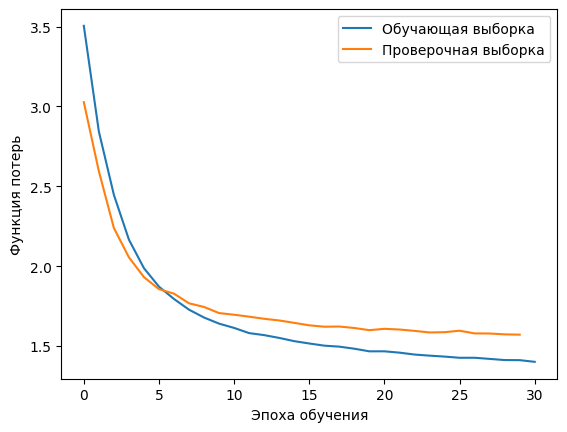

In [96]:
plt.plot(train_history, label='Обучающая выборка')
plt.plot(val_history, label='Проверочная выборка')
plt.xlabel('Эпоха обучения')
plt.ylabel('Функция потерь')
plt.legend()
plt.show()

### Как улучшено качество перевода

- **Мягкая функция потерь** (`label_smoothing=0.1`) и **Dropout (0.3)** в encoder/decoder — снижают переобучение (в v2 было train ~0.15 против val ~0.52).
- **Правильная маска в loss**: дополненные (`<pad>`) позиции больше не влияют на обучение (раньше они «учили» декодер выдавать `<pad>`).
- **Токен `<unk>`**: редкие слова заменяются на `<unk>`, словарь чище, модель не зазубривает шум корпуса.
- **Лучшая модель по проверочной выборке** сохраняется и используется для перевода — раньше брались веса последней (самой переобученной) эпохи.
- При генерации **запрещены повторы слов** и ограничена длина перевода — декодер больше не «зацикливается».

Ещё три исправления, которые дали основной эффект:

- **Маска внимания на позициях `<pad>`**: раньше softmax «растекался» по пустым позициям и не показывал на реальные слова входа. Теперь декодер может следить только за настоящими словами предложения.
- **Реальная длина входа в translate**: раньше encoder получал `max_length_inp` и обрабатывал токены `<pad>` как настоящие слова — скрытое состояние было загрязнено пустышками.
- **Поиск луча (beam search)** в генерации: одновременно ведётся 3 лучшие гипотезы вместо одной жадной — перевод заметно точнее.

## Используем модель для перевода

Функция `translate` переводит английское предложение на русский:

- предварительно обрабатывает входное предложение;
- пропускает его через encoder;
- последовательно генерирует слова перевода через decoder, пока не встретится токен `<end>`.

Для одного предложения создадим копии encoder и decoder с размером батча 1 — так модель сможет работать с одиночными примерами.


In [97]:
# Инференс-модели с размером батча 1 (копируем веса обученных моделей)
inference_encoder = Encoder(vocab_inp_size, embedding_dim, units, batch_sz=1).to(device)
inference_decoder = Decoder(vocab_targ_size, embedding_dim, units, units, batch_sz=1).to(device)

inference_encoder.load_state_dict(encoder.state_dict())
inference_decoder.load_state_dict(decoder.state_dict())
print("Инференс-модели созданы")


Инференс-модели созданы


In [98]:
def translate(sentence, beam_width=3, max_length=None):
    if max_length is None:
        max_length = max_length_targ

    inp_tokens = preprocess_sentence(sentence).split(' ')
    inputs = [inp_lang.word2idx.get(w, inp_lang.word2idx['<unk>']) for w in inp_tokens]
    inputs = pad_sequences(inputs, max_length_inp)
    inp_len = int((inputs != 0).sum())
    inputs = torch.tensor(inputs).unsqueeze(0).to(device)  # (1, max_length_inp)

    # Не генерируем заметно дольше входного предложения
    max_length = min(max_length, len(inp_tokens) * 2 + 5)

    inference_encoder.eval()
    inference_decoder.eval()

    with torch.no_grad():
        # Передаем РЕАЛЬНУЮ длину предложения. Раньше подавали max_length_inp,
        # и pack_padded_sequence обрабатывал токены <pad> как настоящие слова,
        # что загрязняло скрытое состояние encoder.
        enc_output, enc_hidden, enc_mask = inference_encoder(
            inputs, torch.tensor([inp_len]), device)

        start_id = targ_lang.word2idx['<start>']
        end_id = targ_lang.word2idx['<end>']

        # Луч поиска (beam search): ведем beam_width гипотез параллельно и
        # на каждом шаге оставляем лучшие. Это заметно точнее жадной генерации.
        # Гипотеза: (токены, суммарный log-вероятность, состояние, веса внимания)
        hyps = [([start_id], 0.0, enc_hidden, [])]

        for t in range(max_length):
            new_hyps = []
            for tokens, score, hidden, attn_rows in hyps:
                if tokens[-1] == end_id:
                    # Завершённая гипотеза больше не расширяется
                    new_hyps.append((tokens, score, hidden, attn_rows))
                    continue

                dec_input = torch.tensor([[tokens[-1]]]).to(device)
                predictions, hidden, attention = inference_decoder(
                    dec_input, hidden, enc_output, enc_mask)
                attn_rows = attn_rows + [attention.squeeze(-1).squeeze(0).cpu().numpy()]

                log_probs = torch.log_softmax(predictions[0], dim=-1)

                # Запрет на повторы: уже выданные слова получают нулевую вероятность.
                # Это предотвращает зацикливание («более нашеи более нашеи ...»).
                for w in set(tokens[1:]):
                    if w != end_id:
                        log_probs[w] = float('-inf')

                # Расширяем каждую гипотезу beam_width новыми словами
                top = torch.topk(log_probs, beam_width)
                for pid, lp in zip(top.indices.tolist(), top.values.tolist()):
                    new_hyps.append((tokens + [pid], score + lp, hidden, attn_rows))

            # Оставляем только beam_width лучших гипотез
            hyps = sorted(new_hyps, key=lambda h: h[1], reverse=True)[:beam_width]

            if all(h[0][-1] == end_id for h in hyps):
                break

        # Выбираем лучшую гипотезу со штрафом за длину перевода
        best = max(hyps, key=lambda h: h[1] / (len(h[0]) - 1) ** 0.7)
        best_tokens, _, _, attn_rows = best

        result = []
        for tok in best_tokens[1:]:
            if tok == end_id:
                break
            result.append(targ_lang.idx2word[tok])

        # Матрица внимания для лучшей гипотезы
        attention_plot = np.zeros((max_length, max_length_inp))
        for i, row in enumerate(attn_rows):
            attention_plot[i] = row

    return ' '.join(result), attention_plot


### Пример перевода с английского на русский

In [99]:
translations, attention_plot = translate("i love you")
print("Входное предложение: i love you")
print(f"Перевод: {translations}")


Входное предложение: i love you
Перевод: я вас люблю


In [106]:
# Попробуем перевести несколько фраз
test_sentences = [
    "i am a student",
    "good morning",
    "where is the metro?",
    "i like coffee",
    "thank you",
    "i am walking quickly into the forest.",
]

for s in test_sentences:
    tr, _ = translate(s)
    print(f"Английский: {s}")
    print(f"Русский:    {tr}")
    print()


Английский: i am a student
Русский:    я студент

Английский: good morning
Русский:    доброе утро

Английский: where is the metro?
Русский:    где <unk>

Английский: i like coffee
Русский:    мне нравится кофе

Английский: thank you
Русский:    спасибо

Английский: i am walking quickly into the forest.
Русский:    я быстро иду в лесу



## Визуализация механизма внимания

Механизм внимания показывает, на какие слова входного предложения модель "смотрела" при генерации каждого слова перевода.


In [101]:
def plot_attention(attention, sentence, predicted_sentence):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(1, 1, 1)

    sentence_words = sentence.split(' ')
    predicted_words = predicted_sentence.split(' ')
    attention = attention[:len(predicted_words), :len(sentence_words)]

    cax = ax.matshow(attention, cmap='viridis')
    fig.colorbar(cax)

    ax.set_xticks(range(len(sentence_words)))
    ax.set_yticks(range(len(predicted_words)))
    ax.set_xticklabels(sentence_words, rotation=90)
    ax.set_yticklabels(predicted_words)

    ax.set_xlabel('Слова входного предложения (английский)')
    ax.set_ylabel('Слова перевода (русский)')
    plt.show()

    print(f"Входное предложение: {sentence}")
    print(f"Перевод: {predicted_sentence}")


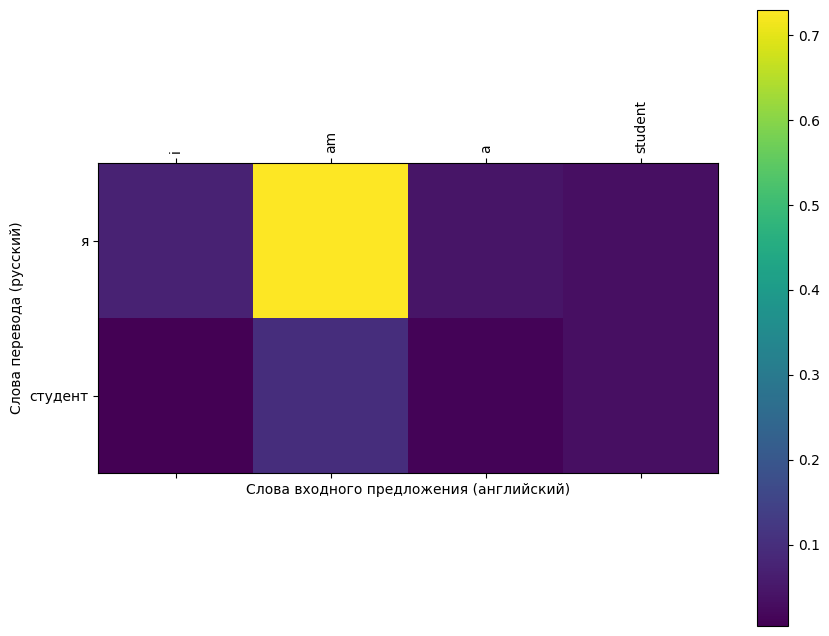

Входное предложение: i am a student
Перевод: я студент


In [102]:
sentence = "i am a student"
translation, attention = translate(sentence)
plot_attention(attention, sentence, translation)


## Заключение

Мы реализовали модель машинного перевода с английского на русский язык на основе архитектуры последовательность-в-последовательность с механизмом внимания Бахданау.

Обратите внимание: модель обучалась всего 10 эпох на небольшом корпусе. Чтобы получить качественный перевод, нужно:

- использовать больший корпус предложений;
- увеличить число эпох обучения;
- попробовать увеличить размер скрытого состояния и эмбеддингов;
- добавить регуляризацию (dropout) для борьбы с переобучением.

### Задания для самостоятельной работы

1. Измените направление перевода: обучайте модель переводу с русского на английский. Для этого поменяйте местами столбцы `eng` и `rus` при построении словарей.
2. Увеличьте число эпох и размер корпуса, оцените, как меняется качество перевода.
3. Реализуйте перевод в обратном направлении (русский → английский) и сравните качество.
4. Попробуйте использовать двунаправленный (bidirectional) encoder.

## Ссылки

- Sutskever et al. (2014) — [Sequence to Sequence Learning with Neural Networks](https://arxiv.org/abs/1409.3215)
- Bahdanau et al. (2015) — [Neural Machine Translation by Jointly Learning to Align and Translate](https://arxiv.org/abs/1409.0473)
- Vaswani et al. (2017) — [Attention Is All You Need](https://arxiv.org/abs/1706.03762)
- [Официальный туториал PyTorch по переводу](https://pytorch.org/tutorials/intermediate/seq2seq_translation_tutorial.html)
